In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

(1000, 2000)


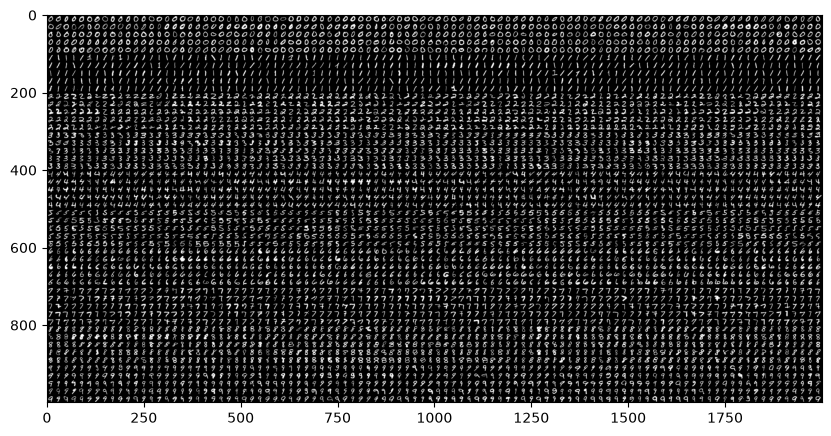

In [2]:
image= cv2.imread('digits.png',0)
print(image.shape)
plt.figure(figsize=(10,10))
plt.imshow(image, cmap='gray')

In [3]:
cells= [np.hsplit(row, 100) for row in np.vsplit(image, 50)]
cells= np.array(cells)
cells.shape

(50, 100, 20, 20)

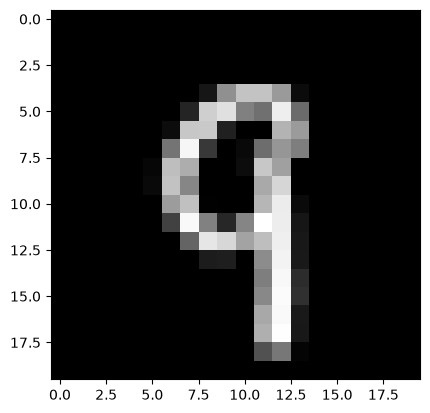

In [4]:
plt.imshow(cells[49,85, :, :], cmap='gray')

In [5]:
train= cells[:, :50].reshape(-1, 400).astype(np.float32)
test= cells[:, 50:100].reshape(-1, 400).astype(np.float32)
print(train.shape)
print(test.shape)

(2500, 400)
(2500, 400)


<h2 dir='rtl'>ایجاد لیبل</h2>

In [6]:
k= np.arange(10)
train_labels= np.repeat(k, 250)[:, np.newaxis]
test_labels= train_labels.copy()
test_labels.shape

(2500, 1)

In [7]:
knn= cv2.ml.KNearest_create()
knn.train(train, cv2.ml.ROW_SAMPLE, train_labels)

True

In [8]:
ret, result, neighbours, dist= knn.findNearest(test, k= 5)
matches= result==test_labels
correct= np.count_nonzero(matches)
accuracy= correct* 100.0/result.size
print(accuracy)

91.76


<h1 dir='rtl'>کار روی یک دیتاست از UCI</h1>

In [9]:
data= np.loadtxt('letter-recognition.data', dtype= 'float32', delimiter= ',', converters= {0: lambda ch: ord(ch)-ord('A')})
data.shape

(20000, 17)

In [10]:
train, test= np.vsplit(data, 2)
print(train.shape)
print(test.shape)

y_train= train[:, :1]
x_train= train[:, 1:]
print(x_train.shape)
print(y_train.shape)

y_test= test[:, :1]
x_test= test[:, 1:]
print(y_test.shape)
print(x_test.shape)

(10000, 17)
(10000, 17)
(10000, 16)
(10000, 1)
(10000, 1)
(10000, 16)


In [11]:
knn= cv2.ml.KNearest_create()
knn.train(x_train, cv2.ml.ROW_SAMPLE, y_train)

True

In [12]:
ret, result, neighbours, dist= knn.findNearest(x_test, k=5)
matches= result == y_test
correct= np.count_nonzero(matches)
accuracy= correct* 100.0/result.size
print(accuracy)

93.06
